<a href="https://colab.research.google.com/github/loreeente/JORGE-LORENTE-TFG/blob/main/Ingenieria%20del%20Dato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# PASO 0 - Conexión con Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [ ]:
# Comprobamos que los ficheros están donde deben
import os

DATA_DIR = '/content/drive/MyDrive/TFG_Lorente/data'

print(f"¿Existe la carpeta? {os.path.exists(DATA_DIR)}")
print("\nFicheros encontrados:")
for f in sorted(os.listdir(DATA_DIR)):
    print(" -", f)

In [ ]:
# ============================================================
# PASO 1 - Carga de datos bursátiles
# ============================================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Pandas:", pd.__version__)
print("Numpy :", np.__version__)

In [ ]:
# Diccionario: nombre_fichero -> (ticker, sector)
TICKERS = {
    'Datos históricos de BBVA (BBVA).csv':              ('BBVA', 'Financiero'),
    'Datos históricos de Banco de Sabadell (SABE).csv': ('SAB',  'Financiero'),
    'Datos históricos de Bankinter (BKT).csv':          ('BKT',  'Financiero'),
    'Datos históricos de CaixaBank (CABK).csv':         ('CABK', 'Financiero'),
    'Datos históricos de Mapfre (MAP).csv':             ('MAP',  'Financiero'),
    'Datos históricos de Santander (SAN) .csv':         ('SAN',  'Financiero'),
    'Datos históricos de Cellnex Telecom (CLNX).csv':   ('CLNX', 'Energético'),
    'Datos históricos de Endesa (ELE).csv':             ('ELE',  'Energético'),
    'Datos históricos de Iberdrola (IBE).csv':          ('IBE',  'Energético'),
    'Datos históricos de Naturgy Energy (NTGY) .csv':   ('NTGY', 'Energético'),
    'Datos históricos de Repsol (REP).csv':             ('REP',  'Energético'),
}

print(f"Total de empresas a cargar: {len(TICKERS)}")
print(f"Financieras: {sum(1 for _, (_, s) in TICKERS.items() if s == 'Financiero')}")
print(f"Energéticas: {sum(1 for _, (_, s) in TICKERS.items() if s == 'Energético')}")

In [ ]:
def parse_volume(v):
    """Convierte '4,32M' -> 4_320_000 (float)"""
    if pd.isna(v):
        return np.nan
    s = str(v).strip().replace(',', '.')
    multiplicador = 1
    if s.endswith('M'):
        multiplicador = 1_000_000
        s = s[:-1]
    elif s.endswith('K'):
        multiplicador = 1_000
        s = s[:-1]
    elif s.endswith('B'):
        multiplicador = 1_000_000_000
        s = s[:-1]
    try:
        return float(s) * multiplicador
    except ValueError:
        return np.nan

def parse_pct(v):
    """Convierte '0,72 %' -> 0.0072 (float, en decimal)"""
    if pd.isna(v):
        return np.nan
    s = str(v).replace('%', '').replace(',', '.').strip()
    try:
        return float(s) / 100.0
    except ValueError:
        return np.nan

# Pequeño test para confirmar que funcionan
print("Test parse_volume:")
print(f"  '4,32M' -> {parse_volume('4,32M'):,.0f}")
print(f"  '850K'  -> {parse_volume('850K'):,.0f}")
print(f"\nTest parse_pct:")
print(f"  '0,72 %' -> {parse_pct('0,72 %')}")
print(f"  '-1,71 %' -> {parse_pct('-1,71 %')}")

In [ ]:
def cargar_accion(nombre_fichero, ticker, sector, data_dir):
    """
    Carga un fichero CSV de Investing.com y devuelve un DataFrame limpio.
    """
    ruta = f"{data_dir}/{nombre_fichero}"

    # Leer el CSV con los parámetros correctos para formato europeo
    df = pd.read_csv(
        ruta,
        sep=';',          # separador europeo
        skiprows=1,       # saltamos la primera fila (título)
        decimal=','       # decimales con coma
    )

    # Renombrar columnas a inglés (más limpio para programar)
    df = df.rename(columns={
        'Fecha':    'Date',
        'Último':   'Close',
        'Apertura': 'Open',
        'Máximo':   'High',
        'Mínimo':   'Low',
        'Vol.':     'Volume',
        '% var.':   'PctChange'
    })

    # Convertir fecha de formato 'dd.mm.yyyy' a tipo datetime
    df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')

    # Limpiar volumen y porcentaje con nuestras funciones
    df['Volume']    = df['Volume'].apply(parse_volume)
    df['PctChange'] = df['PctChange'].apply(parse_pct)

    # Añadir las columnas identificadoras
    df['Ticker'] = ticker
    df['Sector'] = sector

    # Ordenar por fecha (los CSV vienen del más reciente al más antiguo)
    df = df.sort_values('Date').reset_index(drop=True)

    # Reordenar columnas para que sea más legible
    return df[['Date', 'Ticker', 'Sector', 'Open', 'High', 'Low',
               'Close', 'Volume', 'PctChange']]

In [ ]:
# Probamos cargar solo BBVA
DATA_DIR = '/content/drive/MyDrive/TFG_Lorente/data'

bbva = cargar_accion(
    nombre_fichero='Datos históricos de BBVA (BBVA).csv',
    ticker='BBVA',
    sector='Financiero',
    data_dir=DATA_DIR
)

print(f"Shape: {bbva.shape}")
print(f"Periodo: {bbva['Date'].min().date()} → {bbva['Date'].max().date()}")
print(f"\nPrimeras 3 filas:")
print(bbva.head(3))
print(f"\nÚltimas 3 filas:")
print(bbva.tail(3))
print(f"\nTipos de datos:")
print(bbva.dtypes)

In [ ]:
# Cargamos las 11 acciones en bucle
lista_dataframes = []

for nombre_fichero, (ticker, sector) in TICKERS.items():
    print(f"Cargando {ticker:5s} ({sector:11s})...", end=" ")
    df_accion = cargar_accion(nombre_fichero, ticker, sector, DATA_DIR)
    lista_dataframes.append(df_accion)
    print(f"✔ {len(df_accion)} filas")

# Concatenamos todos los DataFrames en uno solo (formato panel largo)
stocks = pd.concat(lista_dataframes, ignore_index=True)

print(f"\n{'='*50}")
print(f"DATASET BURSÁTIL COMPLETO")
print(f"{'='*50}")
print(f"Shape total: {stocks.shape}")
print(f"Tickers: {sorted(stocks['Ticker'].unique())}")

In [ ]:
# Comprobación: número de filas por ticker, fechas mínimas y máximas
resumen = stocks.groupby('Ticker').agg(
    n_filas=('Date', 'size'),
    fecha_min=('Date', 'min'),
    fecha_max=('Date', 'max'),
    nulos_close=('Close', lambda x: x.isna().sum()),
    nulos_volume=('Volume', lambda x: x.isna().sum())
)
print(resumen)

In [ ]:
# Cabeza y cola del dataset combinado
print("Primeras 3 filas (BBVA - octubre 2020):")
print(stocks.head(3))

print("\nÚltimas 3 filas (REP - octubre 2025):")
print(stocks.tail(3))

print(f"\n¿Cuántos sectores tenemos?")
print(stocks['Sector'].value_counts())

In [ ]:
# ============================================================
# PASO 3 - Carga del VIX (índice del miedo)
# ============================================================
vix = pd.read_csv(
    f"{DATA_DIR}/Datos históricos del S&P 500 VIX.csv",
    sep=';',
    skiprows=1,
    decimal=','
)

print(f"Shape inicial: {vix.shape}")
print(f"Columnas originales: {list(vix.columns)}")
print(f"\nPrimeras 3 filas:")
print(vix.head(3))

In [ ]:
# Convertimos la fecha y nos quedamos solo con el cierre
vix['Date'] = pd.to_datetime(vix['Fecha'], format='%d.%m.%Y')

# Renombramos 'Último' (cierre) a 'VIX' y nos quedamos solo con eso
vix = vix.rename(columns={'Último': 'VIX'})[['Date', 'VIX']]

# Ordenamos por fecha (los CSV de Investing van del más reciente al más antiguo)
vix = vix.sort_values('Date').reset_index(drop=True)

print(f"Shape final: {vix.shape}")
print(f"Periodo: {vix['Date'].min().date()} → {vix['Date'].max().date()}")
print(f"\nVIX min: {vix['VIX'].min():.2f}")
print(f"VIX max: {vix['VIX'].max():.2f}")
print(f"VIX media: {vix['VIX'].mean():.2f}")
print(f"\nPrimeras 3 filas:")
print(vix.head(3))
print(f"\nÚltimas 3 filas:")
print(vix.tail(3))

In [ ]:
# ============================================================
# PASO 4 - Carga del IPC (inflación) del INE
# ============================================================
ipc = pd.read_csv(
    f"{DATA_DIR}/INFLACION IPC.csv",
    sep='\t',           # ← TSV (separado por tabuladores)
    encoding='latin-1', # ← encoding español del INE
    decimal=','         # ← decimales con coma
)

print(f"Shape inicial: {ipc.shape}")
print(f"Columnas: {list(ipc.columns)}")
print(f"\nPrimeras 5 filas:")
print(ipc.head(5))

In [ ]:
# ¿Qué grupos hay?
print("Grupos ECOICOP únicos:")
for g in ipc['Grupos ECOICOP'].unique()[:5]:
    print(f"  - {g}")
print(f"  ... ({ipc['Grupos ECOICOP'].nunique()} grupos en total)")

# ¿Qué tipos de dato hay?
print("\nTipos de dato únicos:")
for t in ipc['Tipo de dato'].unique():
    print(f"  - {t}")

In [ ]:
# Filtramos: solo Índice general + Variación anual (= inflación interanual)
ipc = ipc[
    (ipc['Grupos ECOICOP'] == 'Índice general') &
    (ipc['Tipo de dato']   == 'Variación anual')
].copy()

print(f"Filas tras filtro: {len(ipc)}")

# Convertimos el periodo '2025M10' a fecha (1 de cada mes)
# Cambiamos 'M' por '-' para que quede '2025-10', y añadimos '-01'
ipc['Date'] = pd.to_datetime(
    ipc['Periodo'].str.replace('M', '-') + '-01'
)

# Renombramos 'Total' a 'IPC_YoY' (Year over Year = interanual)
ipc = ipc.rename(columns={'Total': 'IPC_YoY'})[['Date', 'IPC_YoY']]

# Ordenamos por fecha
ipc = ipc.sort_values('Date').reset_index(drop=True)

print(f"Periodo: {ipc['Date'].min().date()} → {ipc['Date'].max().date()}")
print(f"\nIPC min: {ipc['IPC_YoY'].min():.2f}%")
print(f"IPC max: {ipc['IPC_YoY'].max():.2f}%")
print(f"IPC media: {ipc['IPC_YoY'].mean():.2f}%")
print(f"\nPrimeras 5 filas:")
print(ipc.head())
print(f"\nÚltimas 5 filas:")
print(ipc.tail())

In [ ]:
# ============================================================
# PASO 5 - Carga de los tipos del BCE
# ============================================================
bce = pd.read_csv(
    f"{DATA_DIR}/tipos_de_interes_aplicados_por_el_banco_central_europeo_(bce).csv",
    encoding='utf-8-sig',  # ← UTF-8 con BOM (típico de algunos exportadores)
    sep=';',
    decimal=',',
    quotechar='"'
)

print(f"Shape inicial: {bce.shape}")
print(f"Columnas: {list(bce.columns)}")
print(f"\nPrimeras 5 filas:")
print(bce.head())
print(f"\nÚltimas 5 filas (¡aquí veremos la metadata basura!):")
print(bce.tail())

In [ ]:
# Filtramos: solo filas donde 'Año' es numérico (descarta la metadata final)
bce = bce[pd.to_numeric(bce['Año'], errors='coerce').notna()].copy()

# Convertimos 'Año' a entero
bce['Año'] = bce['Año'].astype(int)

print(f"Filas tras limpiar metadata: {len(bce)}")
print(f"\nÚltimas 5 filas (ahora deberían ser todas datos válidos):")
print(bce.tail())

In [ ]:
# Diccionario para traducir meses en español a número
MESES = {
    'Enero': 1,    'Febrero': 2,   'Marzo': 3,      'Abril': 4,
    'Mayo': 5,     'Junio': 6,     'Julio': 7,      'Agosto': 8,
    'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12
}

# Mapeamos el mes a número
bce['Mes'] = bce['Periodo'].map(MESES)

# Construimos la fecha (1 del mes correspondiente)
bce['Date'] = pd.to_datetime(dict(
    year=bce['Año'],
    month=bce['Mes'],
    day=1
))

# Renombramos las tasas a nombres cortos
bce = bce.rename(columns={
    'Tasa de depósito (DFR)':              'BCE_DFR',
    'Tasa de facilidad de préstamo (MLF)': 'BCE_MLF',
    'Tipo de Interés (MRO)':               'BCE_MRO'
})

# Nos quedamos solo con las columnas que necesitamos, ordenadas por fecha
bce = bce[['Date', 'BCE_DFR', 'BCE_MLF', 'BCE_MRO']].sort_values('Date').reset_index(drop=True)

print(f"Shape final: {bce.shape}")
print(f"Periodo: {bce['Date'].min().date()} → {bce['Date'].max().date()}")
print(f"\n¡OJO! Solo hay datos cuando el BCE cambia tipos, no es una serie mensual continua.")
print(f"\nPrimeras 5 filas (cambios más antiguos):")
print(bce.head())
print(f"\nÚltimas 10 filas (cambios recientes - veréis la subida agresiva 2022-23):")
print(bce.tail(10))

In [ ]:
# ============================================================
# PASO 6 - Carga de los ratios financieros
# ============================================================
ratios_raw = pd.read_excel(
    f"{DATA_DIR}/ratios tfg.xlsx",
    sheet_name='Hoja1',
    header=None  # ← cargamos sin cabecera para inspeccionar la estructura real
)

print(f"Shape: {ratios_raw.shape}")
print(f"\nVista de las primeras 10 filas (vamos a ver la estructura real):")
print(ratios_raw.head(10))

In [ ]:
# Recortamos: desde la fila 3 (datos), columnas 3 a 7 (D, E, F, G, H)
ratios = ratios_raw.iloc[3:, 3:8].copy()

# Asignamos nombres a las columnas (los teníamos en la fila 2 del Excel)
ratios.columns = ['Ticker', 'Year', 'PE', 'ROE', 'DE']

# Reseteamos índice
ratios = ratios.reset_index(drop=True)

print(f"Shape: {ratios.shape}")
print(f"\nPrimeras 12 filas (verás cómo el Ticker está vacío en muchas filas):")
print(ratios.head(12))

In [ ]:
# Forward-fill del ticker: rellena hacia abajo el último valor no nulo
ratios['Ticker'] = ratios['Ticker'].ffill()

# Eliminamos filas donde Year esté vacío (por si hay filas en blanco al final)
ratios = ratios.dropna(subset=['Year'])

# Convertimos Year a entero
ratios['Year'] = ratios['Year'].astype(int)

# Convertimos los ratios a numéricos (vienen como strings en algunos casos)
for col in ['PE', 'ROE', 'DE']:
    ratios[col] = pd.to_numeric(ratios[col], errors='coerce')

print(f"Shape final: {ratios.shape}")
print(f"Tickers únicos: {sorted(ratios['Ticker'].unique())}")
print(f"\nRatios completos:")
print(ratios.to_string())

In [ ]:
# Convertimos Year en una fecha (1 de enero de cada año)
ratios['Date'] = pd.to_datetime(ratios['Year'].astype(str) + '-01-01')

# Reordenamos columnas
ratios = ratios[['Date', 'Ticker', 'Year', 'PE', 'ROE', 'DE']]
ratios = ratios.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f"Shape final: {ratios.shape}")
print(f"\nPrimeras 10 filas:")
print(ratios.head(10))
print(f"\nResumen estadístico:")
print(ratios[['PE', 'ROE', 'DE']].describe().round(2))

In [ ]:
# ============================================================
# PASO 7 - Homogeneización temporal
# ============================================================

# Calendario común: días en que cotizaron las acciones (días de mercado del IBEX)
trading_days = pd.DatetimeIndex(sorted(stocks['Date'].unique()))

print(f"Días de mercado en el calendario: {len(trading_days)}")
print(f"Periodo: {trading_days.min().date()} → {trading_days.max().date()}")
print(f"\nPrimeros 5 días: {trading_days[:5].date.tolist()}")
print(f"Últimos 5 días:  {trading_days[-5:].date.tolist()}")

In [ ]:
def expandir_a_diario(df_baja_freq, trading_days, columnas_valor):
    """
    Coge un DataFrame con columna 'Date' y lo reindexa al calendario diario,
    aplicando forward-fill para rellenar los días intermedios.

    Args:
        df_baja_freq: DataFrame con 'Date' y las columnas de valores
        trading_days: DatetimeIndex con las fechas objetivo
        columnas_valor: lista de nombres de columnas a propagar

    Returns:
        DataFrame con una fila por trading day, con los valores propagados
    """
    df_expandido = (
        df_baja_freq
        .set_index('Date')[columnas_valor]   # Date como índice
        .reindex(trading_days, method='ffill')  # reindex al calendario diario + ffill
        .reset_index()                       # vuelve Date a columna
        .rename(columns={'index': 'Date'})   # asegura el nombre de la columna
    )
    return df_expandido

In [ ]:
# Expandimos IPC (mensual) → diario
ipc_diario = expandir_a_diario(ipc, trading_days, ['IPC_YoY'])

# Expandimos BCE (por reunión) → diario
bce_diario = expandir_a_diario(bce, trading_days, ['BCE_DFR', 'BCE_MLF', 'BCE_MRO'])

# Expandimos VIX (también diario, pero con calendario USA) → diario IBEX
vix_diario = expandir_a_diario(vix, trading_days, ['VIX'])

print(f"IPC diario:  {ipc_diario.shape}")
print(f"BCE diario:  {bce_diario.shape}")
print(f"VIX diario:  {vix_diario.shape}")

print(f"\n--- Muestra IPC diario (vamos a ver el ffill en acción) ---")
print(ipc_diario.head(10))

In [ ]:
# Expandimos ratios para cada empresa por separado
lista_ratios_expandidos = []

for ticker in ratios['Ticker'].unique():
    sub = ratios[ratios['Ticker'] == ticker]
    sub_expandido = expandir_a_diario(sub, trading_days, ['PE', 'ROE', 'DE'])
    sub_expandido['Ticker'] = ticker  # añadimos el ticker que perdimos
    lista_ratios_expandidos.append(sub_expandido)

# Concatenamos todos
ratios_diario = pd.concat(lista_ratios_expandidos, ignore_index=True)

print(f"Ratios diario: {ratios_diario.shape}")
print(f"Esperado: {len(trading_days)} días × 11 tickers = {len(trading_days)*11}")
print(f"\nMuestra (BBVA, los primeros días):")
print(ratios_diario[ratios_diario['Ticker']=='BBVA'].head(5))
print(f"\n¿Hay nulos en los ratios expandidos?")
print(ratios_diario[['PE','ROE','DE']].isna().sum())

In [ ]:
# Aplicamos backward-fill por ticker para rellenar los nulos del inicio
for col in ['PE', 'ROE', 'DE']:
    ratios_diario[col] = ratios_diario.groupby('Ticker')[col].transform(
        lambda x: x.bfill()
    )

print("Nulos después del bfill:")
print(ratios_diario[['PE', 'ROE', 'DE']].isna().sum())

print(f"\nMuestra BBVA primeros días (ya no debe haber NaN):")
print(ratios_diario[ratios_diario['Ticker']=='BBVA'].head(5))

In [ ]:
# ============================================================
# PASO 8 - Merge: dataset maestro
# ============================================================

# Partimos de stocks (la tabla más detallada) y vamos añadiendo fuentes
master = (
    stocks
    .merge(ipc_diario,    on='Date',            how='left')
    .merge(bce_diario,    on='Date',            how='left')
    .merge(vix_diario,    on='Date',            how='left')
    .merge(ratios_diario, on=['Date', 'Ticker'], how='left')
)

print(f"Shape del dataset maestro: {master.shape}")
print(f"\nColumnas:")
for c in master.columns:
    print(f"  - {c}")

In [ ]:
print("Nulos por columna:")
print(master.isna().sum())

print(f"\nTotal filas: {len(master)}")
print(f"Filas completas (sin ningún nulo): {len(master.dropna())}")

In [ ]:
print("Primera fila completa:")
print(master.iloc[0].to_dict())

print(f"\n\nMuestra de 3 filas (primera y última de BBVA, primera de SAN):")
print(master[(master['Ticker']=='BBVA')].iloc[[0, -1]])
print()
print(master[(master['Ticker']=='SAN')].iloc[[0]])

In [ ]:
# ============================================================
# PASO 9 - Feature Engineering
# ============================================================

def add_features(g):
    """
    Añade features técnicas a la serie de UNA empresa.

    Parámetro:
        g: DataFrame de UNA sola empresa, ordenado por fecha.

    Devuelve:
        El mismo DataFrame con nuevas columnas añadidas.
    """
    # Aseguramos que está ordenado por fecha (CRÍTICO para shift/rolling)
    g = g.copy().sort_values('Date').reset_index(drop=True)

    # ----- 1. RETORNO LOGARÍTMICO -----
    # log(P_t / P_{t-1}) ≈ (P_t - P_{t-1}) / P_{t-1} para cambios pequeños
    # Lo preferimos al retorno simple porque es aditivo (sumar 5 retornos diarios = retorno semanal)
    g['LogReturn'] = np.log(g['Close'] / g['Close'].shift(1))

    # ----- 2. LAGS (valores pasados) -----
    # Le damos al modelo el precio y el retorno de hace 1, 5, 10 y 20 días
    # Esto le permite aprender patrones del tipo "si bajó hace 5 días, mañana suele recuperarse"
    for L in [1, 5, 10, 20]:
        g[f'Close_lag{L}']  = g['Close'].shift(L)
        g[f'Return_lag{L}'] = g['LogReturn'].shift(L)

    # ----- 3. VOLATILIDAD ROLLING (riesgo realizado) -----
    # Desviación estándar de los retornos en una ventana móvil
    # Es un proxy del riesgo: cuanto más alta, más "agitada" está la acción
    g['Vol_20d'] = g['LogReturn'].rolling(window=20).std()  # ~1 mes
    g['Vol_60d'] = g['LogReturn'].rolling(window=60).std()  # ~3 meses

    # ----- 4. MEDIAS MÓVILES (tendencia) -----
    # Promedio del precio en los últimos N días
    # SMA = Simple Moving Average. Análisis técnico clásico.
    g['SMA_20'] = g['Close'].rolling(window=20).mean()
    g['SMA_60'] = g['Close'].rolling(window=60).mean()

    # ----- 5. MOMENTUM (variación a medio plazo) -----
    # ¿Cuánto ha variado el precio en los últimos 20 / 60 días?
    # Mom > 0 = está subiendo, Mom < 0 = está bajando
    g['Mom_20'] = g['Close'] / g['Close'].shift(20) - 1
    g['Mom_60'] = g['Close'] / g['Close'].shift(60) - 1

    return g

print("Función add_features definida ✔")

Función add_features definida ✔


In [ ]:
# Aplicamos add_features empresa por empresa
lista_con_features = []

for ticker, grupo in master.groupby('Ticker'):
    grupo_con_features = add_features(grupo)
    lista_con_features.append(grupo_con_features)

# Concatenamos todo de vuelta en un único DataFrame
master_fe = pd.concat(lista_con_features, ignore_index=True)

print(f"Shape antes de feature engineering: {master.shape}")
print(f"Shape después de feature engineering: {master_fe.shape}")
print(f"\nColumnas nuevas que hemos añadido:")
nuevas = [c for c in master_fe.columns if c not in master.columns]
for c in nuevas:
    print(f"  + {c}")

Shape antes de feature engineering: (14091, 17)
Shape después de feature engineering: (14091, 32)

Columnas nuevas que hemos añadido:
  + LogReturn
  + Close_lag1
  + Return_lag1
  + Close_lag5
  + Return_lag5
  + Close_lag10
  + Return_lag10
  + Close_lag20
  + Return_lag20
  + Vol_20d
  + Vol_60d
  + SMA_20
  + SMA_60
  + Mom_20
  + Mom_60


In [ ]:
# Vemos las primeras 25 filas de BBVA
sample_bbva = master_fe[master_fe['Ticker']=='BBVA'].head(25)
print("BBVA - primeras 25 filas con features (algunas columnas):")
print(sample_bbva[['Date', 'Close', 'LogReturn', 'Close_lag1', 'Return_lag5',
                   'Vol_20d', 'SMA_20', 'Mom_20']].round(4))

BBVA - primeras 25 filas con features (algunas columnas):
         Date  Close  LogReturn  Close_lag1  Return_lag5  Vol_20d  SMA_20  \
0  2020-10-14  2.268        NaN         NaN          NaN      NaN     NaN   
1  2020-10-15  2.257    -0.0049       2.268          NaN      NaN     NaN   
2  2020-10-16  2.334     0.0335       2.257          NaN      NaN     NaN   
3  2020-10-19  2.356     0.0094       2.334          NaN      NaN     NaN   
4  2020-10-20  2.428     0.0301       2.356          NaN      NaN     NaN   
5  2020-10-21  2.394    -0.0141       2.428          NaN      NaN     NaN   
6  2020-10-22  2.427     0.0137       2.394      -0.0049      NaN     NaN   
7  2020-10-23  2.495     0.0276       2.427       0.0335      NaN     NaN   
8  2020-10-26  2.436    -0.0239       2.495       0.0094      NaN     NaN   
9  2020-10-27  2.406    -0.0124       2.436       0.0301      NaN     NaN   
10 2020-10-28  2.366    -0.0168       2.406      -0.0141      NaN     NaN   
11 2020-10-29  2.3

In [ ]:
print("Resumen de nulos por columna (después del feature engineering):")
print(master_fe.isna().sum().sort_values(ascending=False).head(15))

Resumen de nulos por columna (después del feature engineering):
Vol_60d         660
Mom_60          660
SMA_60          649
Return_lag20    231
Mom_20          220
Vol_20d         220
Close_lag20     220
SMA_20          209
Return_lag10    121
Close_lag10     110
Return_lag5      66
Close_lag5       55
Volume           22
Return_lag1      22
LogReturn        11
dtype: int64


In [ ]:
def add_targets(g):
    """
    Añade las variables target a la serie de UNA empresa.

    Parámetro:
        g: DataFrame de UNA sola empresa, con features ya añadidas.

    Devuelve:
        El mismo DataFrame con los targets añadidos.
    """
    g = g.copy().sort_values('Date').reset_index(drop=True)

    # ----- TARGET DE REGRESIÓN: precio dentro de 30 días -----
    g['Target_Price_30d']  = g['Close'].shift(-30)

    # También guardamos el retorno a 30 días (útil para análisis)
    g['Target_Return_30d'] = g['Close'].shift(-30) / g['Close'] - 1

    # ----- TARGET DE CLASIFICACIÓN: riesgo de caída >10% en 30 días -----
    # Calculamos el mínimo del Close en los PRÓXIMOS 30 días
    # (truco: invertimos la serie, hacemos rolling, y volvemos a invertir)
    rolling_future_min = g['Close'][::-1].rolling(30, min_periods=1).min()[::-1]

    # Lo desplazamos 1 día hacia atrás para que NO incluya el día actual
    # (queremos el mínimo en t+1 ... t+30, no en t ... t+30)
    g['FutureMin_30d'] = rolling_future_min.shift(-1)

    # Drawdown máximo: cuánto cayó el precio desde el actual hasta el mínimo futuro
    # Si es <= -0.10 (cayó al menos 10%) → es un evento de riesgo
    g['MaxDrawdown_30d'] = g['FutureMin_30d'] / g['Close'] - 1

    g['Target_Risk'] = (g['MaxDrawdown_30d'] <= -0.10).astype(int)

    return g

# Aplicamos a cada ticker
lista_con_targets = []
for ticker, grupo in master_fe.groupby('Ticker'):
    grupo_con_targets = add_targets(grupo)
    lista_con_targets.append(grupo_con_targets)

master_fe = pd.concat(lista_con_targets, ignore_index=True)

print(f"Shape final del dataset: {master_fe.shape}")
print(f"\nColumnas target añadidas:")
for c in ['Target_Price_30d', 'Target_Return_30d', 'FutureMin_30d',
          'MaxDrawdown_30d', 'Target_Risk']:
    print(f"  + {c}")

Shape final del dataset: (14091, 37)

Columnas target añadidas:
  + Target_Price_30d
  + Target_Return_30d
  + FutureMin_30d
  + MaxDrawdown_30d
  + Target_Risk


In [ ]:
# Vemos BBVA con sus targets
sample = master_fe[master_fe['Ticker']=='BBVA'][['Date', 'Close', 'Target_Price_30d',
                                                  'Target_Return_30d', 'FutureMin_30d',
                                                  'MaxDrawdown_30d', 'Target_Risk']]
print("BBVA - filas 30 a 40 (ya tienen target porque hay 'futuro'):")
print(sample.iloc[30:40].round(4))

print(f"\nÚltimas filas de BBVA (las últimas 30 NO deberían tener target):")
print(sample.tail(5).round(4))

BBVA - filas 30 a 40 (ya tienen target porque hay 'futuro'):
         Date  Close  Target_Price_30d  Target_Return_30d  FutureMin_30d  \
30 2020-11-25  3.785             4.276             0.1297          3.770   
31 2020-11-26  3.770             4.251             0.1276          3.881   
32 2020-11-27  3.958             4.256             0.0753          3.881   
33 2020-11-30  3.930             4.196             0.0677          3.881   
34 2020-12-01  4.005             4.174             0.0422          3.881   
35 2020-12-02  4.080             4.088             0.0020          3.881   
36 2020-12-03  4.078             4.140             0.0152          3.881   
37 2020-12-04  4.304             4.022            -0.0655          3.881   
38 2020-12-07  4.200             4.051            -0.0355          3.881   
39 2020-12-08  4.155             4.035            -0.0289          3.881   

    MaxDrawdown_30d  Target_Risk  
30          -0.0040            0  
31           0.0294            0

In [ ]:
# ¿Qué porcentaje de filas son eventos de riesgo (1)?
print("Distribución del Target_Risk (global):")
print(master_fe['Target_Risk'].value_counts(normalize=True).round(3))
print(f"\nNúmero absoluto:")
print(master_fe['Target_Risk'].value_counts())

print(f"\n--- Tasa de eventos de riesgo POR EMPRESA ---")
risk_por_ticker = master_fe.groupby('Ticker')['Target_Risk'].mean().sort_values(ascending=False)
print((risk_por_ticker * 100).round(1).to_string())

Distribución del Target_Risk (global):
Target_Risk
0    0.839
1    0.161
Name: proportion, dtype: float64

Número absoluto:
Target_Risk
0    11827
1     2264
Name: count, dtype: int64

--- Tasa de eventos de riesgo POR EMPRESA ---
Ticker
CLNX    27.2
SAB     22.8
SAN     20.4
REP     17.9
BBVA    17.1
CABK    17.0
BKT     14.8
NTGY    13.1
ELE     10.6
IBE      9.8
MAP      6.1


In [ ]:
# ============================================================
# PASO 11 - EDA y visualizaciones
# ============================================================
import matplotlib.pyplot as plt

# Configuración de estilo (gráficos limpios y profesionales)
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 120,
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'legend.fontsize': 9
})

# Carpeta donde guardaremos las figuras (en tu Drive)
import os
FIGS_DIR = '/content/drive/MyDrive/TFG_Lorente/figs'
os.makedirs(FIGS_DIR, exist_ok=True)

print(f"Figuras se guardarán en: {FIGS_DIR}")

Figuras se guardarán en: /content/drive/MyDrive/TFG_Lorente/figs


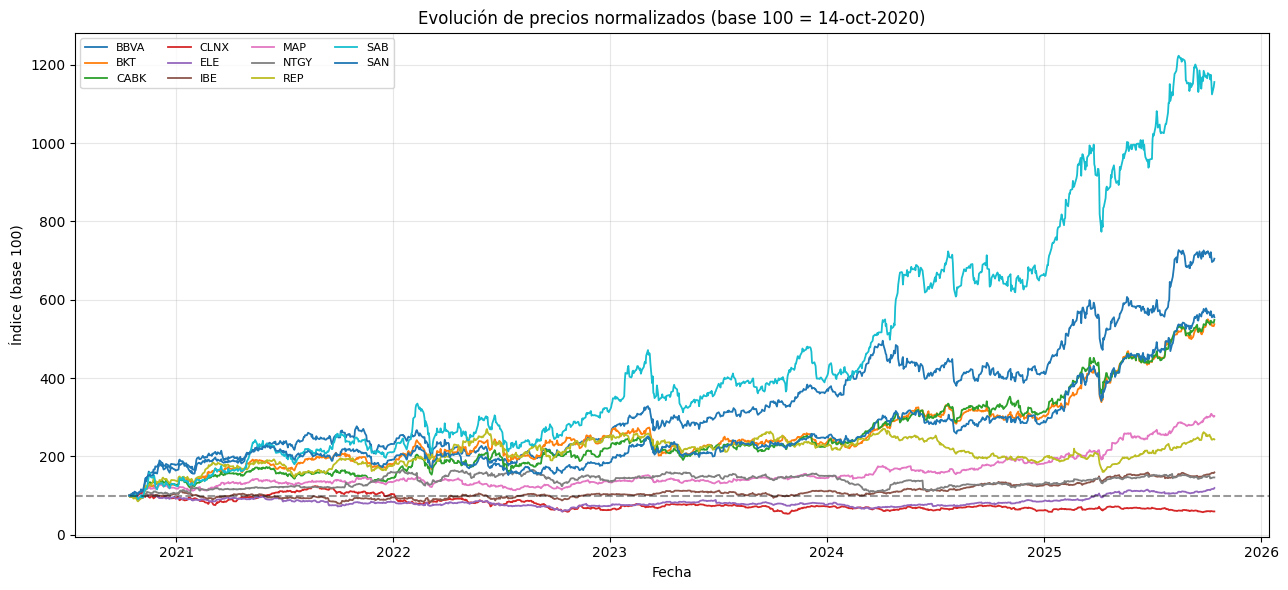

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

for ticker in sorted(master_fe['Ticker'].unique()):
    sub = master_fe[master_fe['Ticker'] == ticker]
    base = sub['Close'].iloc[0]  # primer precio
    ax.plot(sub['Date'], sub['Close'] / base * 100, label=ticker, lw=1.3)

ax.set_title('Evolución de precios normalizados (base 100 = 14-oct-2020)')
ax.set_ylabel('Índice (base 100)')
ax.set_xlabel('Fecha')
ax.legend(ncol=4, fontsize=8, loc='upper left')
ax.axhline(100, color='black', ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/01_precios_normalizados.png', bbox_inches='tight')
plt.show()

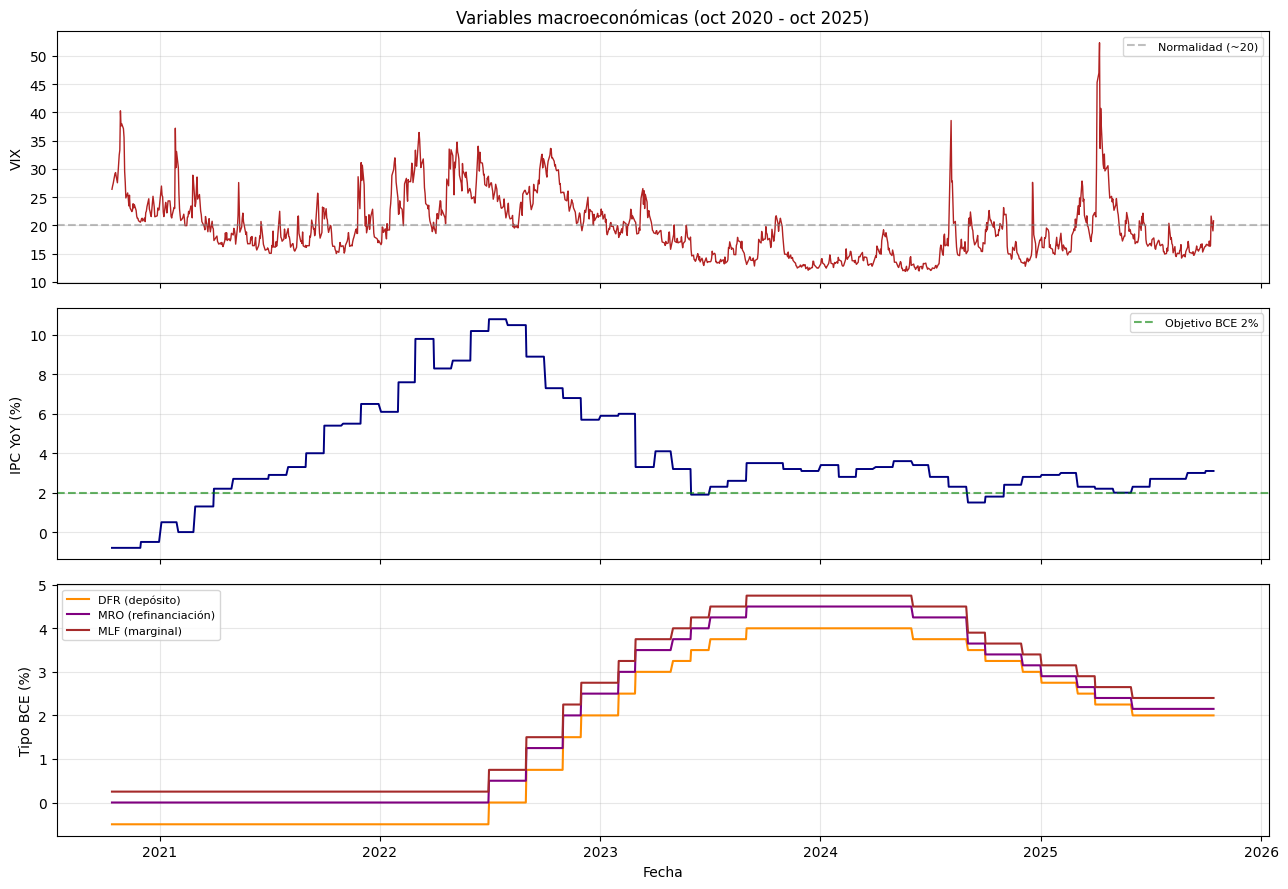

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# Cogemos un solo ticker porque las macro son iguales para todos
sub = master_fe[master_fe['Ticker'] == 'BBVA']

# Subplot 1: VIX
axes[0].plot(sub['Date'], sub['VIX'], color='firebrick', lw=1)
axes[0].set_ylabel('VIX')
axes[0].set_title('Variables macroeconómicas (oct 2020 - oct 2025)')
axes[0].axhline(20, color='gray', ls='--', alpha=0.5, label='Normalidad (~20)')
axes[0].legend(loc='upper right', fontsize=8)

# Subplot 2: IPC
axes[1].plot(sub['Date'], sub['IPC_YoY'], color='navy', lw=1.4)
axes[1].axhline(2, color='green', ls='--', alpha=0.6, label='Objetivo BCE 2%')
axes[1].set_ylabel('IPC YoY (%)')
axes[1].legend(loc='upper right', fontsize=8)

# Subplot 3: Tipos BCE
axes[2].plot(sub['Date'], sub['BCE_DFR'], color='darkorange', lw=1.5, label='DFR (depósito)')
axes[2].plot(sub['Date'], sub['BCE_MRO'], color='purple',     lw=1.5, label='MRO (refinanciación)')
axes[2].plot(sub['Date'], sub['BCE_MLF'], color='brown',      lw=1.5, label='MLF (marginal)')
axes[2].set_ylabel('Tipo BCE (%)')
axes[2].set_xlabel('Fecha')
axes[2].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/02_macro.png', bbox_inches='tight')
plt.show()

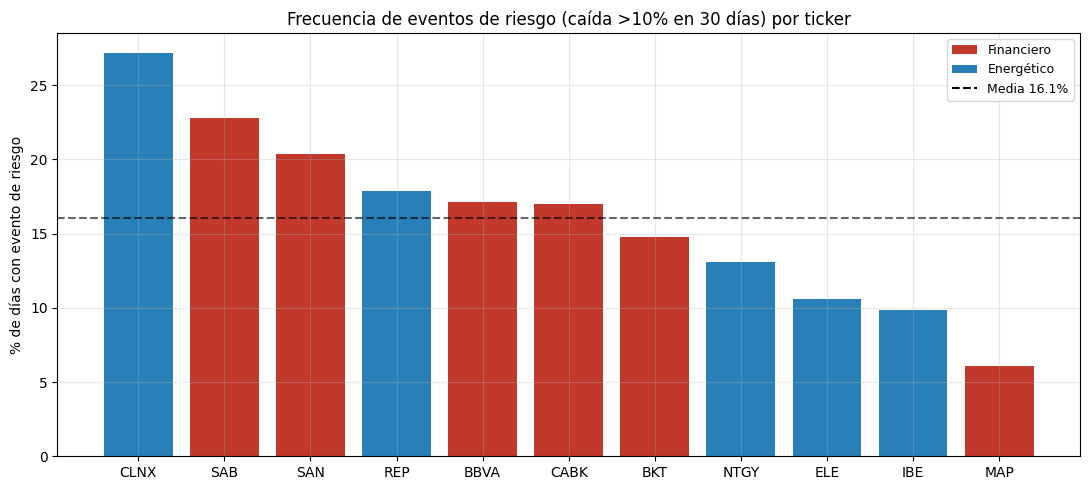

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

risk_rate = master_fe.groupby('Ticker')['Target_Risk'].mean().sort_values(ascending=False)

# Coloreamos según sector
colores = []
for t in risk_rate.index:
    sector = master_fe[master_fe['Ticker']==t]['Sector'].iloc[0]
    colores.append('#c0392b' if sector == 'Financiero' else '#2980b9')

ax.bar(risk_rate.index, risk_rate.values * 100, color=colores)
ax.axhline(risk_rate.mean() * 100, color='black', ls='--', alpha=0.6,
           label=f'Media: {risk_rate.mean()*100:.1f}%')
ax.set_ylabel('% de días con evento de riesgo')
ax.set_title('Frecuencia de eventos de riesgo (caída >10% en 30 días) por ticker')
ax.legend()

# Leyenda manual de colores
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#c0392b', label='Financiero'),
    Patch(facecolor='#2980b9', label='Energético'),
    plt.Line2D([0], [0], color='black', ls='--', label=f'Media {risk_rate.mean()*100:.1f}%')
], loc='upper right')

plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/03_riesgo_por_ticker.png', bbox_inches='tight')
plt.show()

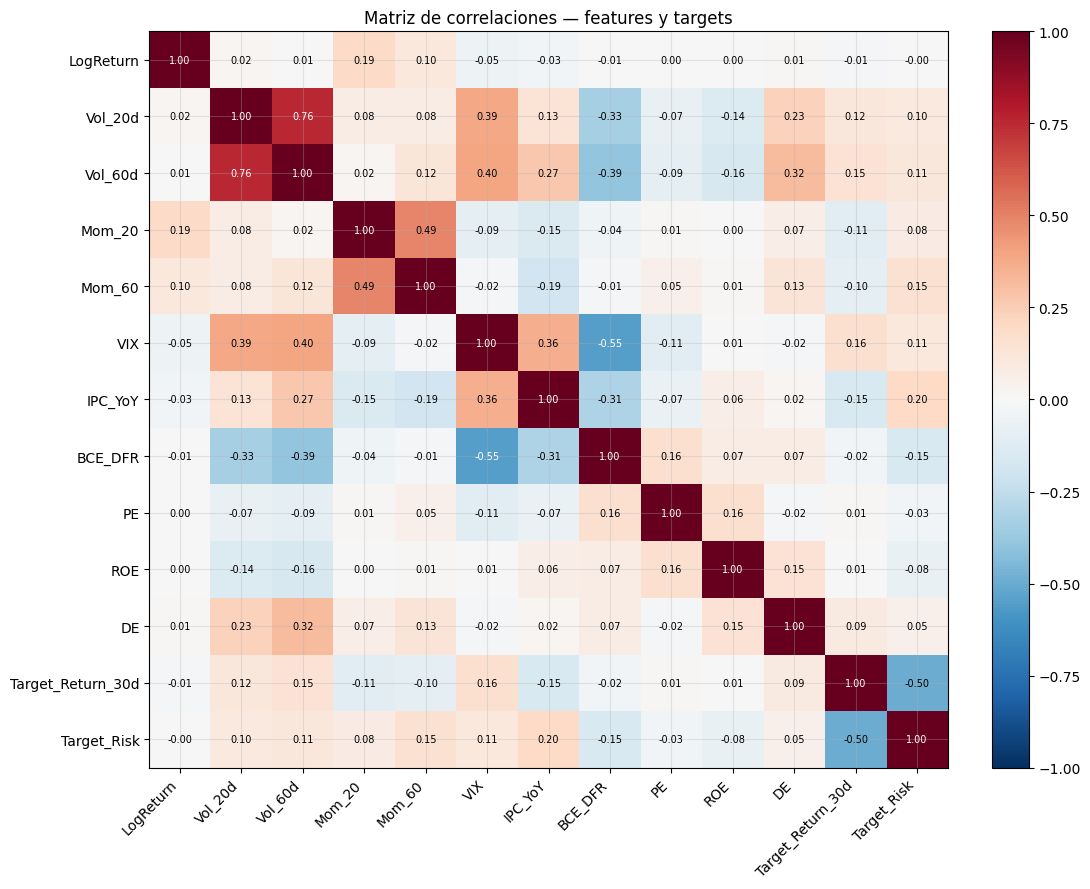

In [ ]:
import numpy as np

# Features y targets
cols_corr = ['LogReturn', 'Vol_20d', 'Vol_60d', 'Mom_20', 'Mom_60',
             'VIX', 'IPC_YoY', 'BCE_DFR', 'PE', 'ROE', 'DE',
             'Target_Return_30d', 'Target_Risk']

corr = master_fe[cols_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(cols_corr)))
ax.set_xticklabels(cols_corr, rotation=45, ha='right')
ax.set_yticks(range(len(cols_corr)))
ax.set_yticklabels(cols_corr)

# Anotaciones numéricas
for i in range(len(cols_corr)):
    for j in range(len(cols_corr)):
        valor = corr.iloc[i, j]
        color = 'white' if abs(valor) > 0.5 else 'black'
        ax.text(j, i, f'{valor:.2f}', ha='center', va='center',
                color=color, fontsize=7)

plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Matriz de correlaciones — features y targets')
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/04_correlaciones.png', bbox_inches='tight')
plt.show()

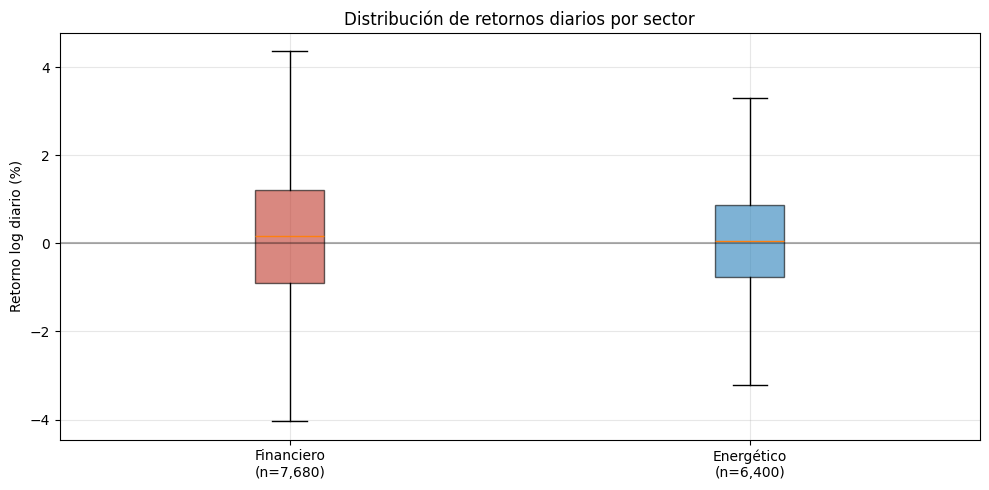

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

datos = []
labels_sectores = []
for sector in ['Financiero', 'Energético']:
    sub = master_fe[(master_fe['Sector']==sector) & master_fe['LogReturn'].notna()]
    datos.append(sub['LogReturn'] * 100)  # en porcentaje
    labels_sectores.append(f"{sector}\n(n={len(sub):,})")

bp = ax.boxplot(datos, labels=labels_sectores, showfliers=False, patch_artist=True)

# Coloreamos las cajas
colores_box = ['#c0392b', '#2980b9']
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Retorno log diario (%)')
ax.set_title('Distribución de retornos diarios por sector')
ax.axhline(0, color='black', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/05_boxplot_sector.png', bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# PASO 12 - Persistencia del dataset maestro
# ============================================================

# Carpeta de salida (la creamos si no existe)
OUT_DIR = '/content/drive/MyDrive/TFG_Lorente/output'
os.makedirs(OUT_DIR, exist_ok=True)

# Guardamos el dataset maestro completo
ruta_dataset = f'{OUT_DIR}/dataset_maestro.csv'
master_fe.to_csv(ruta_dataset, index=False)

# Comprobamos
import os
tamaño_kb = os.path.getsize(ruta_dataset) / 1024
print(f"✔ Dataset guardado en: {ruta_dataset}")
print(f"  Shape: {master_fe.shape}")
print(f"  Tamaño: {tamaño_kb:,.1f} KB ({tamaño_kb/1024:.2f} MB)")

✔ Dataset guardado en: /content/drive/MyDrive/TFG_Lorente/output/dataset_maestro.csv
  Shape: (14091, 37)
  Tamaño: 5,554.5 KB (5.42 MB)


In [ ]:
print("=" * 60)
print("RESUMEN DEL DATASET MAESTRO — PILAR 1")
print("=" * 60)

print(f"\n📊 DIMENSIONES")
print(f"  Filas totales:     {len(master_fe):,}")
print(f"  Columnas:          {master_fe.shape[1]}")
print(f"  Tickers:           {master_fe['Ticker'].nunique()}")
print(f"  Días de mercado:   {master_fe['Date'].nunique():,}")

print(f"\n📅 PERIODO")
print(f"  Desde: {master_fe['Date'].min().date()}")
print(f"  Hasta: {master_fe['Date'].max().date()}")
print(f"  Duración: {(master_fe['Date'].max() - master_fe['Date'].min()).days / 365.25:.1f} años")

print(f"\n🏢 EMPRESAS POR SECTOR")
print(master_fe.groupby('Sector')['Ticker'].nunique().to_string())

print(f"\n🎯 TARGET DE CLASIFICACIÓN")
print(f"  Tasa global de eventos de riesgo: {master_fe['Target_Risk'].mean()*100:.1f}%")
print(f"  Total de eventos:                 {int(master_fe['Target_Risk'].sum()):,}")

print(f"\n📐 COLUMNAS POR FAMILIA")
print(f"  Identificadores: 3  (Date, Ticker, Sector)")
print(f"  Bursátiles:      6  (OHLC + Volume + PctChange)")
print(f"  Macro:           5  (IPC, BCE x3, VIX)")
print(f"  Fundamentales:   3  (PE, ROE, DE)")
print(f"  Features:       14  (LogReturn + 8 lags + 2 vol + 2 SMA + 2 Mom)")
print(f"  Targets:         5  (Price_30d, Return_30d, FutureMin, MaxDD, Risk)")
print(f"  ────────────────")
print(f"  TOTAL:          36  ✔")

RESUMEN DEL DATASET MAESTRO — PILAR 1

📊 DIMENSIONES
  Filas totales:     14,091
  Columnas:          37
  Tickers:           11
  Días de mercado:   1,281

📅 PERIODO
  Desde: 2020-10-14
  Hasta: 2025-10-14
  Duración: 5.0 años

🏢 EMPRESAS POR SECTOR
Sector
Energético    5
Financiero    6

🎯 TARGET DE CLASIFICACIÓN
  Tasa global de eventos de riesgo: 16.1%
  Total de eventos:                 2,264

📐 COLUMNAS POR FAMILIA
  Identificadores: 3  (Date, Ticker, Sector)
  Bursátiles:      6  (OHLC + Volume + PctChange)
  Macro:           5  (IPC, BCE x3, VIX)
  Fundamentales:   3  (PE, ROE, DE)
  Features:       14  (LogReturn + 8 lags + 2 vol + 2 SMA + 2 Mom)
  Targets:         5  (Price_30d, Return_30d, FutureMin, MaxDD, Risk)
  ────────────────
  TOTAL:          36  ✔
